In [ ]:
!pip install yfinance
!pip install plotly
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

In [ ]:
gold = yf.download("GC=F",start = "2020-01-01")
oil = yf.download("CL=F",start =  "2020-01-01")

/tmp/ipykernel_919/81878610.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F",start = "2020-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_919/81878610.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil = yf.download("CL=F",start =  "2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
gold.describe().round(2)

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
count,1616.00,1616.00,1616.00,1616.00,1616.00
mean,2361.18,2375.11,2346.66,2360.90,4359.68
std,893.30,903.23,883.47,894.37,22514.82
min,1477.30,1484.00,1452.10,1469.30,0.00
25%,1801.33,1807.98,1792.30,1800.38,95.75
50%,1933.80,1944.95,1924.40,1934.30,309.00
75%,2636.97,2650.43,2622.07,2636.50,830.50
max,5318.40,5586.20,5301.60,5415.70,251274.00


In [ ]:
oil.describe().round(2)

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
count,1616.00,1616.00,1616.00,1616.00,1616.00
mean,70.81,72.21,69.41,70.87,349171.39
std,18.91,19.23,18.55,18.87,170732.68
min,-37.63,13.69,-40.32,-14.00,0.00
25%,61.66,62.88,60.63,61.72,266055.25
50%,71.82,72.99,70.61,71.85,329512.00
75%,81.09,82.33,80.10,81.16,405067.25
max,123.70,130.50,120.79,124.66,2288230.00


In [ ]:
gold['gold_return'] = gold["Close"].pct_change() * 100

In [ ]:
oil['oil_return'] = oil["Close"].pct_change() * 100

In [ ]:
data = pd.DataFrame({
    "Gold_Return": gold['gold_return'],
    "Oil_Return": oil['oil_return'],
    "Gold_Close": gold[('Close', 'GC=F')],
    "Oil_Close  ": oil[('Close', 'CL=F')]
})

<Axes: xlabel='Date'>

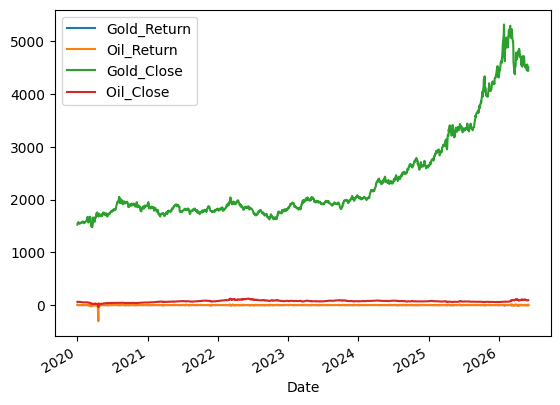

In [ ]:
data.plot()

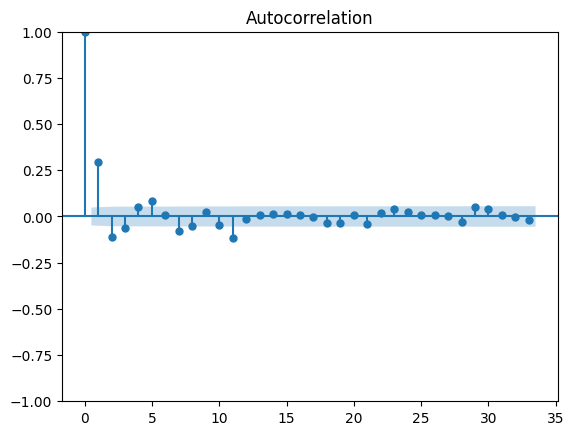

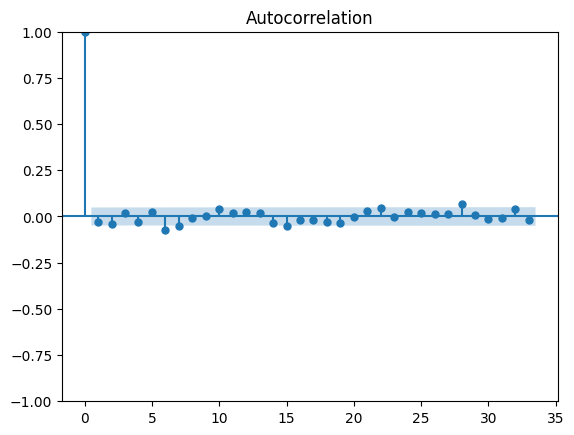

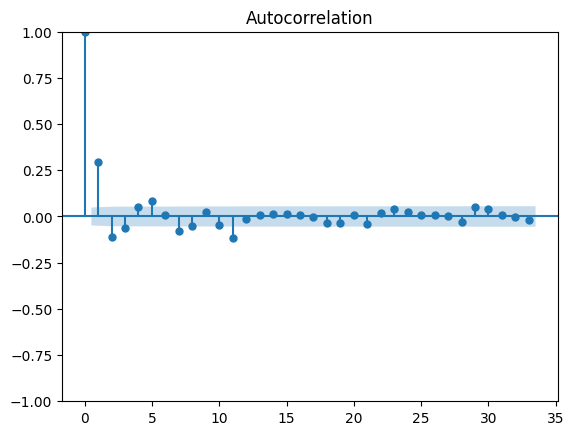

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(gold['gold_return'].dropna())
plot_acf(oil['oil_return'].dropna())

In [ ]:
import statsmodels.api as sm

In [ ]:
gold.describe().round(2)

Price,Close,High,Low,Open,Volume,gold_return
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,
count,1616.00,1616.00,1616.00,1616.00,1616.00,1615.00
mean,2361.18,2375.11,2346.66,2360.90,4359.68,0.07
std,893.30,903.23,883.47,894.37,22514.82,1.17
min,1477.30,1484.00,1452.10,1469.30,0.00,-11.37
25%,1801.33,1807.98,1792.30,1800.38,95.75,-0.47
50%,1933.80,1944.95,1924.40,1934.30,309.00,0.10
75%,2636.97,2650.43,2622.07,2636.50,830.50,0.69
max,5318.40,5586.20,5301.60,5415.70,251274.00,6.08


In [ ]:
oil.describe().round(2)

Price,Close,High,Low,Open,Volume,oil_return
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F,
count,1616.00,1616.00,1616.00,1616.00,1616.00,1615.00
mean,70.81,72.21,69.41,70.87,349171.39,-0.15
std,18.91,19.23,18.55,18.87,170732.68,8.88
min,-37.63,13.69,-40.32,-14.00,0.00,-305.97
25%,61.66,62.88,60.63,61.72,266055.25,-1.38
50%,71.82,72.99,70.61,71.85,329512.00,0.19
75%,81.09,82.33,80.10,81.16,405067.25,1.56
max,123.70,130.50,120.79,124.66,2288230.00,37.66


In [ ]:
df = df[['Gold_Return','Oil_Return']].dropna().round(2)

In [ ]:
x = sm.add_constant(df['Oil_Return'])
model = sm.OLS(df['Gold_Return'], x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Gold_Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.539
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.215
Time:                        15:22:41   Log-Likelihood:                -2551.0
No. Observations:                1615   AIC:                             5106.
Df Residuals:                    1613   BIC:                             5117.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0747      0.029      2.556      0.0